# XGBoost Step-by-Step (Wildfire Detection)

This notebook implements a complete baseline pipeline for wildfire image classification.
It uses classical handcrafted features and an XGBoost classifier for the `fire` vs `nofire` task.

## 1) Environment Setup

Install the required packages for XGBoost and image feature extraction.

> Running this cell once is sufficient.

In [3]:
# Required packages
# If you are using a local virtual environment, installation can also be done from the terminal.

%pip install xgboost scikit-image opencv-python seaborn
print("If installation is complete, restart the kernel once (Kernel -> Restart).")

Note: you may need to restart the kernel to use updated packages.
If installation is complete, restart the kernel once (Kernel -> Restart).


## 2A) Dataset Download (Kaggle)

This step creates the `archive/the_wildfire_dataset_2n_version` directory structure.

Before running the next cell:
- Download the `kaggle.json` API token from your Kaggle account
- Place the file at `~/Downloads/kaggle.json`

In [1]:
# Dataset setup (local)
# Running this cell once is sufficient.

import os
import sys
import json
import subprocess

# 1) Install Kaggle package in the current kernel environment
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle"], check=True)

# 2) Kaggle token file
kaggle_json_downloads = os.path.expanduser("~/Downloads/kaggle.json")
kaggle_json_target = os.path.expanduser("~/.kaggle/kaggle.json")
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

if os.path.exists(kaggle_json_downloads):
    subprocess.run(["cp", kaggle_json_downloads, kaggle_json_target], check=True)
    os.chmod(kaggle_json_target, 0o600)
    print("kaggle.json copied -> ~/.kaggle/kaggle.json")
elif not os.path.exists(kaggle_json_target):
    raise FileNotFoundError(
        "kaggle.json not found. Download the Kaggle API token and place it in ~/Downloads, or add it as ~/.kaggle/kaggle.json."
    )

# 3) Validate JSON structure
with open(kaggle_json_target, "r", encoding="utf-8") as f:
    creds = json.load(f)

username = creds.get("username")
key = creds.get("key")
if not username or not key:
    raise ValueError(
        "Invalid kaggle.json: missing 'username' or 'key'.\n"
        "Expected file format:\n"
        "{\"username\": \"your_kaggle_username\", \"key\": \"your_api_key\"}\n"
        "Re-download it from Kaggle > Account > Create New API Token."
    )

print(f"Kaggle user: {username}")
os.makedirs("archive", exist_ok=True)

# 4) Download dataset
print("\nDownloading dataset...")
base_args = ["datasets", "download", "-d", "elmadafri/the-wildfire-dataset", "-p", "archive"]

# In some environments `python -m kaggle` may fail.
# Try `python -m kaggle.cli` first, then fallback to `kaggle` binary.
cmd_candidates = [
    [sys.executable, "-m", "kaggle.cli", *base_args],
    ["kaggle", *base_args],
]

res = None
for cmd in cmd_candidates:
    try:
        print("Attempted command:", " ".join(cmd))
        res = subprocess.run(cmd, capture_output=True, text=True)
        print("stdout:\n", res.stdout)
        print("stderr:\n", res.stderr)
        if res.returncode == 0:
            break
    except FileNotFoundError as e:
        print("Command not found:", e)

if res is None or res.returncode != 0:
    raise RuntimeError("Kaggle download failed. Check the stderr output above.")

# 5) Unzip archive
print("Extracting zip...")
unzip_res = subprocess.run(
    ["unzip", "-o", "archive/the-wildfire-dataset.zip", "-d", "archive"],
    capture_output=True,
    text=True,
)
print("unzip stdout:\n", unzip_res.stdout[:2000])
print("unzip stderr:\n", unzip_res.stderr)
if unzip_res.returncode != 0:
    raise RuntimeError(f"Unzip failed (exit={unzip_res.returncode}).")

# 6) Verify expected folder structure
print("\nDone. Expected folders available?")
base = "archive/the_wildfire_dataset_2n_version"
for split in ["train", "val", "test"]:
    print(split, os.path.exists(os.path.join(base, split)))

kaggle.json copied -> ~/.kaggle/kaggle.json
Kaggle user: idil12344

Attempted command: /usr/local/bin/python3 -m kaggle.cli datasets download -d elmadafri/the-wildfire-dataset -p archive
stdout:
 Dataset URL: https://www.kaggle.com/datasets/elmadafri/the-wildfire-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
the-wildfire-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)

stderr:
 
Zip aciliyor...
unzip stdout:
 Archive:  archive/the-wildfire-dataset.zip
  inflating: archive/the_wildfire_dataset_2n_version/test/fire/19196558588_267f24b847_o.jpg  
  inflating: archive/the_wildfire_dataset_2n_version/test/fire/20960888741_8c4be2c1df_o.jpg  
  inflating: archive/the_wildfire_dataset_2n_version/test/fire/26131736898_9e6a8cd68f_o.jpg  
  inflating: archive/the_wildfire_dataset_2n_version/test/fire/26549039025_b4cce14ec7_o.jpg  
  inflating: archive/the_wildfire_dataset_2n_version/test/fire/27002088114_aa5cc7f353_o.jpg  
  inflating

## 2) Configure Dataset Path

Set the dataset root directory so all subsequent cells can resolve train/validation/test data correctly.

Expected structure:
- `.../train/fire`, `.../train/nofire`
- `.../val/fire`, `.../val/nofire`
- `.../test/fire`, `.../test/nofire`

In [2]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage.filters import gaussian

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import ParameterSampler

try:
    from xgboost import XGBClassifier
except Exception as e:
    raise RuntimeError(
        "XGBoost import failed. On macOS, run the following commands in terminal:\n"
        "  brew install libomp\n"
        "  python3 -m pip uninstall -y xgboost\n"
        "  python3 -m pip install --no-cache-dir xgboost\n"
        "Then restart the kernel and run this cell again.\n\n"
        f"Original error: {e}"
    )

# This path should be valid when running from the project root
DATASET_ROOT = "archive/the_wildfire_dataset_2n_version"
IMG_SIZE = (224, 224)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CLASS_MAP = {"fire": 1, "nofire": 0}
CLASS_NAMES = ["nofire", "fire"]

for split in ["train", "val", "test"]:
    p = os.path.join(DATASET_ROOT, split)
    print(split, "exists:", os.path.exists(p), "->", p)

train exists: True -> archive/the_wildfire_dataset_2n_version/train
val exists: True -> archive/the_wildfire_dataset_2n_version/val
test exists: True -> archive/the_wildfire_dataset_2n_version/test


## 3) Load and Inspect Data

Load images from each split, validate class counts, and skip corrupted files.

In [16]:
def load_images_from_directory(split_dir, img_size=(224, 224)):
    images, labels, corrupted = [], [], 0
    for class_name in ["fire", "nofire"]:
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: {class_dir} not found")
            continue

        for fname in sorted(os.listdir(class_dir)):
            fpath = os.path.join(class_dir, fname)
            try:
                img = Image.open(fpath).convert("RGB").resize(img_size)
                images.append(np.array(img))
                labels.append(CLASS_MAP[class_name])
            except Exception:
                corrupted += 1
    return np.array(images), np.array(labels), corrupted

X_train_imgs, y_train, c1 = load_images_from_directory(os.path.join(DATASET_ROOT, "train"), IMG_SIZE)
X_val_imgs, y_val, c2 = load_images_from_directory(os.path.join(DATASET_ROOT, "val"), IMG_SIZE)
X_test_imgs, y_test, c3 = load_images_from_directory(os.path.join(DATASET_ROOT, "test"), IMG_SIZE)

print("Corrupted skipped:", c1 + c2 + c3)
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    fire = int((y == 1).sum())
    nofire = int((y == 0).sum())
    print(f"{name}: total={len(y)}, fire={fire}, nofire={nofire}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/Library/Frameworks

Corrupted skipped: 1
Train: total=1887, fire=730, nofire=1157
Val: total=402, fire=156, nofire=246
Test: total=410, fire=159, nofire=251


## 4) Feature Extraction

The feature set combines complementary visual descriptors:
- **HOG**: edge and structural patterns
- **LBP**: local texture representation (useful for smoke-like regions)
- **Color histogram + channel statistics**: color distribution cues related to fire/smoke appearance

Together, these feature groups provide a strong classical ML baseline.

In [4]:
# Feature config
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

LBP_RADIUS = 3
LBP_N_POINTS = 24
LBP_METHOD = "uniform"

HIST_BINS = 32

def extract_hog_features(image_rgb):
    gray = rgb2gray(image_rgb)
    return hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        feature_vector=True,
    )

def extract_lbp_histogram(image_rgb):
    gray = rgb2gray(image_rgb)
    gray_uint8 = (gray * 255).astype(np.uint8)
    lbp = local_binary_pattern(gray_uint8, LBP_N_POINTS, LBP_RADIUS, method=LBP_METHOD)
    n_bins = LBP_N_POINTS + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist

def extract_color_histogram(image_rgb):
    arr = image_rgb.astype(np.float32) / 255.0
    hists = [np.histogram(arr[:, :, c], bins=HIST_BINS, range=(0, 1), density=True)[0] for c in range(3)]
    return np.concatenate(hists)

def extract_color_statistics(image_rgb):
    out = []
    for c in range(3):
        ch = image_rgb[:, :, c].astype(np.float64)
        out.extend([np.mean(ch), np.std(ch)])
    return np.array(out)

def extract_all_features(images, desc="Extracting"):
    feats = []
    total = len(images)
    for i, img in enumerate(images):
        if (i + 1) % 200 == 0 or i == 0 or (i + 1) == total:
            print(f"{desc}: {i+1}/{total}")

        f = np.concatenate([
            extract_hog_features(img),
            extract_lbp_histogram(img),
            extract_color_histogram(img),
            extract_color_statistics(img),
        ])
        feats.append(f)
    return np.array(feats)

start = time.time()
X_train = extract_all_features(X_train_imgs, "Train")
X_val = extract_all_features(X_val_imgs, "Val")
X_test = extract_all_features(X_test_imgs, "Test")
print("Feature extraction time (s):", round(time.time() - start, 1))
print("Feature dim:", X_train.shape[1])

Train: 1/1887
Train: 200/1887
Train: 400/1887
Train: 600/1887
Train: 800/1887
Train: 1000/1887
Train: 1200/1887
Train: 1400/1887
Train: 1600/1887
Train: 1800/1887
Train: 1887/1887
Val: 1/402
Val: 200/402
Val: 400/402
Val: 402/402
Test: 1/410
Test: 200/410
Test: 400/410
Test: 410/410
Feature extraction time (s): 27.0
Feature dim: 6212


## 5) Standardization + XGBoost Training

Feature scales differ across HOG, LBP, histogram, and statistical descriptors; standardization improves optimization stability.

`scale_pos_weight` is used to compensate for class imbalance during XGBoost training.

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / max(n_pos, 1)
print("scale_pos_weight:", round(scale_pos_weight, 3))

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

start = time.time()
xgb.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
print("Train time (s):", round(time.time() - start, 1))

scale_pos_weight: 1.585
Train time (s): 27.1


## 6) Evaluation

Reported metrics:
- Accuracy: overall correctness
- Precision/Recall/F1: class-sensitive performance, especially for `fire`
- ROC-AUC: threshold-independent discrimination quality

In [6]:
def evaluate_split(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}

y_val_pred = xgb.predict(X_val_s)
y_val_proba = xgb.predict_proba(X_val_s)[:, 1]
val_metrics = evaluate_split("Validation", y_val, y_val_pred, y_val_proba)

y_test_pred = xgb.predict(X_test_s)
y_test_proba = xgb.predict_proba(X_test_s)[:, 1]
test_metrics = evaluate_split("Test", y_test, y_test_pred, y_test_proba)

print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES))


Validation
Accuracy : 0.8060
Precision: 0.7468
Recall   : 0.7564
F1-score : 0.7516
ROC-AUC  : 0.9035

Test
Accuracy : 0.8561
Precision: 0.7941
Recall   : 0.8491
F1-score : 0.8207
ROC-AUC  : 0.9293

Classification report (test):
              precision    recall  f1-score   support

      nofire       0.90      0.86      0.88       251
        fire       0.79      0.85      0.82       159

    accuracy                           0.86       410
   macro avg       0.85      0.85      0.85       410
weighted avg       0.86      0.86      0.86       410



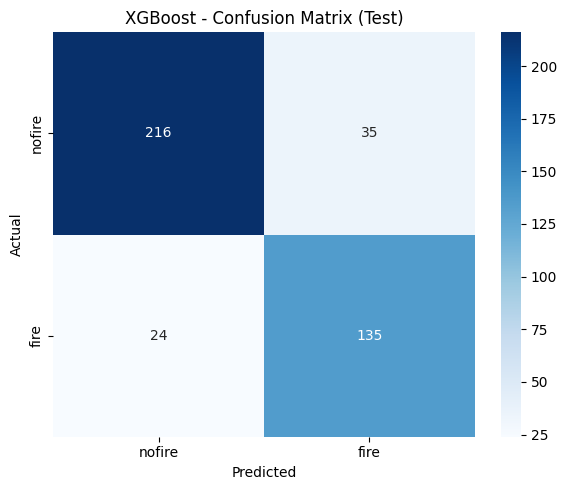

In [7]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

## 7) XGBoost Hyperparameter Tuning (Validation-guided)

Bu adimda sadece XGBoost icin rastgele hiperparametre taramasi yapip en iyi modeli `val F1` uzerinden seciyoruz.

In [9]:
param_distributions = {
    "n_estimators": [300, 500, 700, 900],
    "max_depth": [4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0.0, 0.1, 0.3],
    "reg_lambda": [1.0, 2.0, 5.0],
}

search_trials = list(ParameterSampler(param_distributions, n_iter=18, random_state=RANDOM_STATE))
search_results = []

print(f"Total candidates: {len(search_trials)}")
start = time.time()

for i, params in enumerate(search_trials, start=1):
    candidate = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        **params,
    )
    candidate.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
    val_proba = candidate.predict_proba(X_val_s)[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)
    val_f1 = f1_score(y_val, val_pred)
    val_rec = recall_score(y_val, val_pred)
    val_prec = precision_score(y_val, val_pred)
    val_auc = roc_auc_score(y_val, val_proba)

    row = {
        "trial": i,
        "val_f1": val_f1,
        "val_recall": val_rec,
        "val_precision": val_prec,
        "val_auc": val_auc,
        **params,
    }
    search_results.append(row)
    print(f"{i:02d}/{len(search_trials)} -> F1={val_f1:.4f}, Recall={val_rec:.4f}, AUC={val_auc:.4f}")

search_df = pd.DataFrame(search_results).sort_values(["val_f1", "val_auc"], ascending=False)
best_params = search_df.iloc[0].to_dict()

print("\nSearch time (s):", round(time.time() - start, 1))
print("Best candidate (val F1):")
print(search_df.head(1).T)

best_param_dict = {
    k: best_params[k]
    for k in param_distributions.keys()
}

# Values coming from the DataFrame may be floats; cast integer fields back to int.
for int_key in ["n_estimators", "max_depth", "min_child_weight"]:
    best_param_dict[int_key] = int(round(best_param_dict[int_key]))

xgb_tuned = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    **best_param_dict,
)

xgb_tuned.fit(
    X_train_s,
    y_train,
    eval_set=[(X_val_s, y_val)],
    verbose=False,
)
print("\nTuned model trained.")

Total candidates: 18
01/18 -> F1=0.7524, Recall=0.7692, AUC=0.9037
02/18 -> F1=0.7837, Recall=0.8013, AUC=0.9091
03/18 -> F1=0.7524, Recall=0.7500, AUC=0.9026
04/18 -> F1=0.7461, Recall=0.7628, AUC=0.8937
05/18 -> F1=0.7677, Recall=0.7628, AUC=0.9066
06/18 -> F1=0.7540, Recall=0.7564, AUC=0.9029
07/18 -> F1=0.7562, Recall=0.7756, AUC=0.8998
08/18 -> F1=0.7484, Recall=0.7436, AUC=0.9046
09/18 -> F1=0.7625, Recall=0.7821, AUC=0.9018
10/18 -> F1=0.7688, Recall=0.7885, AUC=0.9053
11/18 -> F1=0.7389, Recall=0.7436, AUC=0.9081
12/18 -> F1=0.7610, Recall=0.7756, AUC=0.9039
13/18 -> F1=0.7619, Recall=0.7692, AUC=0.9045
14/18 -> F1=0.7508, Recall=0.7628, AUC=0.9011
15/18 -> F1=0.7485, Recall=0.7821, AUC=0.8995
16/18 -> F1=0.7697, Recall=0.7821, AUC=0.9035
17/18 -> F1=0.7378, Recall=0.7756, AUC=0.8781
18/18 -> F1=0.7717, Recall=0.7692, AUC=0.9061

Search time (s): 453.3
En iyi aday (val F1):
                           1
trial               2.000000
val_f1              0.783699
val_recall        

## 8) Threshold tuning (F1 + Recall)

Varsayilan `0.5` threshold yerine validation set uzerinden F1 ve Recall dengesini optimize eden threshold secilir.

Secilen threshold: 0.17
threshold    0.170000
f1           0.777778
recall       0.942308
precision    0.662162
score        0.827137
Name: 7, dtype: float64


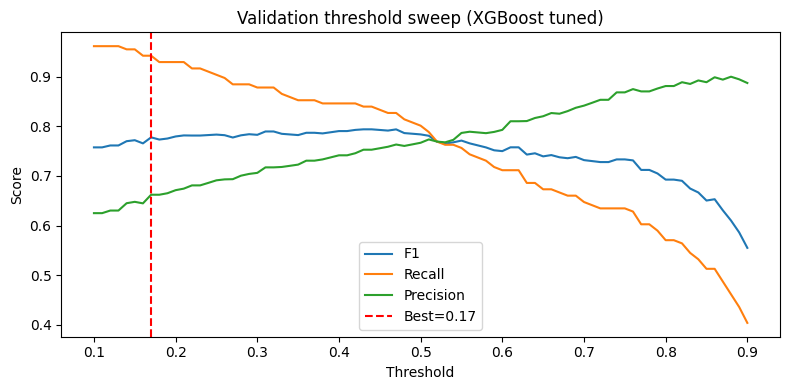

In [10]:
val_proba_tuned = xgb_tuned.predict_proba(X_val_s)[:, 1]
threshold_grid = np.linspace(0.10, 0.90, 81)

th_rows = []
for th in threshold_grid:
    pred = (val_proba_tuned >= th).astype(int)
    f1 = f1_score(y_val, pred)
    rec = recall_score(y_val, pred)
    prec = precision_score(y_val, pred)
    composite = 0.7 * f1 + 0.3 * rec
    th_rows.append({"threshold": th, "f1": f1, "recall": rec, "precision": prec, "score": composite})

th_df = pd.DataFrame(th_rows)
best_th_row = th_df.sort_values(["score", "f1", "recall"], ascending=False).iloc[0]
BEST_THRESHOLD = float(best_th_row["threshold"])

print(f"Secilen threshold: {BEST_THRESHOLD:.2f}")
print(best_th_row)

plt.figure(figsize=(8, 4))
plt.plot(th_df["threshold"], th_df["f1"], label="F1")
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"Best={BEST_THRESHOLD:.2f}")
plt.title("Validation threshold sweep (XGBoost tuned)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

## 9) Tuned model test degerlendirmesi + confusion matrix

                    model  accuracy  precision    recall        f1   roc_auc
1     XGB Tuned (th=0.50)  0.865854   0.805882  0.861635  0.832827  0.930993
0  XGB Baseline (th=0.50)  0.856098   0.794118  0.849057  0.820669  0.929314
2     XGB Tuned (th=0.17)  0.780488   0.645570  0.962264  0.772727  0.930993


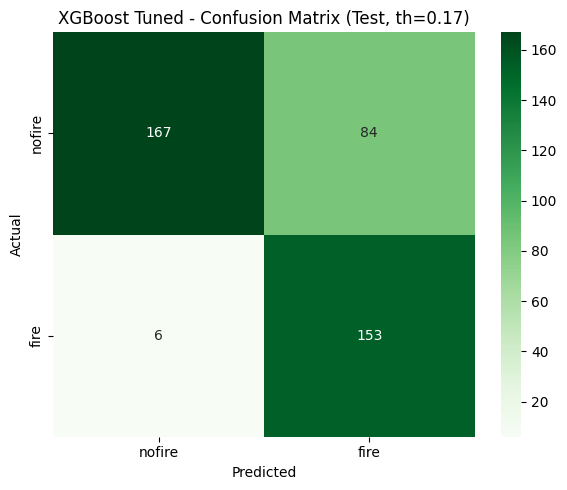


Classification report (tuned + best threshold):
              precision    recall  f1-score   support

      nofire       0.97      0.67      0.79       251
        fire       0.65      0.96      0.77       159

    accuracy                           0.78       410
   macro avg       0.81      0.81      0.78       410
weighted avg       0.84      0.78      0.78       410



In [12]:
def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

# Baseline (eski model)
y_test_prob_base = xgb.predict_proba(X_test_s)[:, 1]
y_test_pred_base = (y_test_prob_base >= 0.5).astype(int)
baseline_test_metrics = compute_metrics(y_test, y_test_pred_base, y_test_prob_base)

# Tuned + default threshold
y_test_prob_tuned = xgb_tuned.predict_proba(X_test_s)[:, 1]
y_test_pred_tuned_default = (y_test_prob_tuned >= 0.5).astype(int)
tuned_test_metrics_default = compute_metrics(y_test, y_test_pred_tuned_default, y_test_prob_tuned)

# Tuned + best threshold
y_test_pred_tuned_bestth = (y_test_prob_tuned >= BEST_THRESHOLD).astype(int)
tuned_test_metrics_bestth = compute_metrics(y_test, y_test_pred_tuned_bestth, y_test_prob_tuned)

compare_main = pd.DataFrame([
    {"model": "XGB Baseline (th=0.50)", **baseline_test_metrics},
    {"model": "XGB Tuned (th=0.50)", **tuned_test_metrics_default},
    {"model": f"XGB Tuned (th={BEST_THRESHOLD:.2f})", **tuned_test_metrics_bestth},
]).sort_values("f1", ascending=False)

print(compare_main)

cm_tuned = confusion_matrix(y_test, y_test_pred_tuned_bestth)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"XGBoost Tuned - Confusion Matrix (Test, th={BEST_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()

print("\nClassification report (tuned + best threshold):")
print(classification_report(y_test, y_test_pred_tuned_bestth, target_names=CLASS_NAMES))

## 10) Robustness experiments (blur, haze, brightness)

Ayni test set uzerinde sentetik bozunumlar altinda model davranisini olcuyoruz.

blur feats: 1/410
blur feats: 200/410
blur feats: 400/410
blur feats: 410/410
haze feats: 1/410
haze feats: 200/410
haze feats: 400/410
haze feats: 410/410
brightness feats: 1/410
brightness feats: 200/410
brightness feats: 400/410
brightness feats: 410/410
     scenario  accuracy  precision    recall        f1   roc_auc
0       clean  0.780488   0.645570  0.962264  0.772727  0.930993
1        blur  0.636585   0.518657  0.874214  0.651054  0.775615
2        haze  0.595122   0.489028  0.981132  0.652720  0.891052
3  brightness  0.800000   0.685990  0.893082  0.775956  0.896264


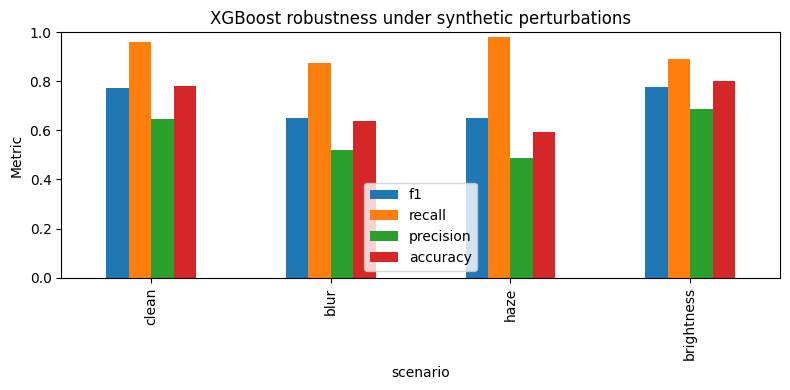

In [13]:
def apply_blur(img, sigma=1.8):
    out = gaussian(img / 255.0, sigma=sigma, channel_axis=2)
    return np.clip(out * 255.0, 0, 255).astype(np.uint8)

def apply_haze(img, alpha=0.30):
    white = np.full_like(img, 255)
    out = (1 - alpha) * img.astype(np.float32) + alpha * white.astype(np.float32)
    return np.clip(out, 0, 255).astype(np.uint8)

def apply_brightness(img, factor=1.35):
    out = img.astype(np.float32) * factor
    return np.clip(out, 0, 255).astype(np.uint8)

def eval_under_perturbation(name, transform_fn):
    transformed_imgs = np.array([transform_fn(img) for img in X_test_imgs])
    Xp = extract_all_features(transformed_imgs, desc=f"{name} feats")
    Xp_s = scaler.transform(Xp)
    prob = xgb_tuned.predict_proba(Xp_s)[:, 1]
    pred = (prob >= BEST_THRESHOLD).astype(int)
    return {"scenario": name, **compute_metrics(y_test, pred, prob)}

robust_rows = [
    {"scenario": "clean", **tuned_test_metrics_bestth},
    eval_under_perturbation("blur", apply_blur),
    eval_under_perturbation("haze", apply_haze),
    eval_under_perturbation("brightness", apply_brightness),
]

robustness_df = pd.DataFrame(robust_rows)
print(robustness_df)

plt.figure(figsize=(8, 4))
plot_df = robustness_df.set_index("scenario")[["f1", "recall", "precision", "accuracy"]]
plot_df.plot(kind="bar", ax=plt.gca())
plt.ylim(0, 1.0)
plt.title("XGBoost robustness under synthetic perturbations")
plt.ylabel("Metric")
plt.tight_layout()
plt.show()

## 11) XGBoost feature importance

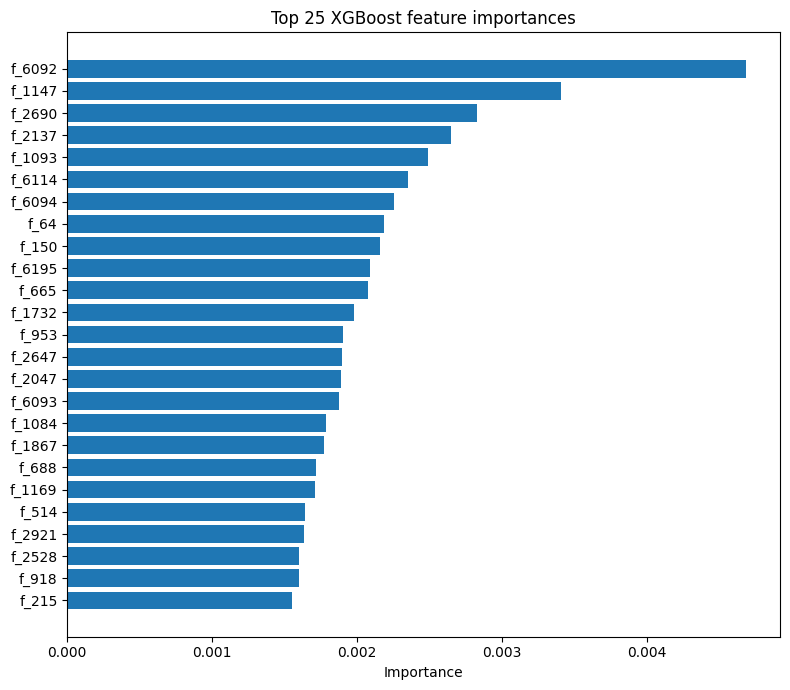

Top 10 feature importances:
     feature  importance
6092  f_6092    0.004681
1147  f_1147    0.003406
2690  f_2690    0.002823
2137  f_2137    0.002647
1093  f_1093    0.002486
6114  f_6114    0.002350
6094  f_6094    0.002255
64      f_64    0.002188
150    f_150    0.002154
6195  f_6195    0.002091


In [14]:
feature_names = [f"f_{i}" for i in range(X_train.shape[1])]
importances = xgb_tuned.feature_importances_

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

top_k = 25
plt.figure(figsize=(8, 7))
plot_imp = imp_df.head(top_k).sort_values("importance", ascending=True)
plt.barh(plot_imp["feature"], plot_imp["importance"])
plt.title(f"Top {top_k} XGBoost feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 feature importances:")
print(imp_df.head(10))

## 12) Error Analysis (Confounder-Focused)

For misclassified samples, this section scans file names for keywords such as `cloud/fog/haze/smoke/mist` to report potential confounder cases.

Total misclassifications: 90 / 410

Error distribution (true -> pred):
     true    pred  count
0    fire  nofire      6
1  nofire    fire     84

Confounder tag distribution:
confounder_tags
none    90
Name: count, dtype: int64

First 10 failure cases:


,index,path,true,pred,proba_fire,confounder_tags
0,29,unknown_test_path_29,fire,nofire,0.004528,none
1,55,unknown_test_path_55,fire,nofire,0.134880,none
2,60,unknown_test_path_60,fire,nofire,0.106013,none
3,74,unknown_test_path_74,fire,nofire,0.134500,none
4,128,unknown_test_path_128,fire,nofire,0.081996,none
5,129,unknown_test_path_129,fire,nofire,0.160963,none
6,160,unknown_test_path_160,nofire,fire,0.343593,none
7,161,unknown_test_path_161,nofire,fire,0.302012,none
8,163,unknown_test_path_163,nofire,fire,0.934178,none
9,167,unknown_test_path_167,nofire,fire,0.412408,none


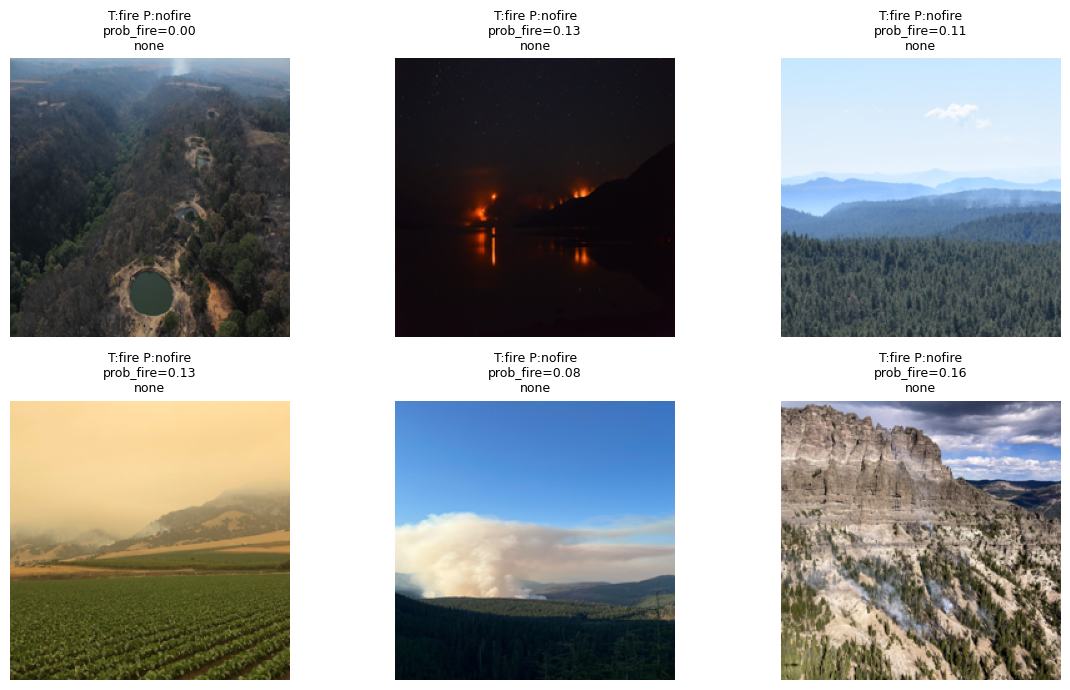

In [17]:
mis_idx = np.where(y_test != y_test_pred_tuned_bestth)[0]
print(f"Total misclassifications: {len(mis_idx)} / {len(y_test)}")

# In older kernel runs, test_paths may be undefined.
if "test_paths" not in globals() or test_paths is None or len(test_paths) != len(y_test):
    test_paths = np.array([f"unknown_test_path_{i}" for i in range(len(y_test))])
    print("Warning: test_paths not found, using placeholder paths.")

error_rows = []
keywords = ["cloud", "fog", "haze", "mist", "smoke"]

for i in mis_idx:
    p = str(test_paths[i]).lower()
    matched = [k for k in keywords if k in p]
    error_rows.append({
        "index": int(i),
        "path": str(test_paths[i]),
        "true": CLASS_NAMES[int(y_test[i])],
        "pred": CLASS_NAMES[int(y_test_pred_tuned_bestth[i])],
        "proba_fire": float(y_test_prob_tuned[i]),
        "confounder_tags": ",".join(matched) if matched else "none",
    })

error_df = pd.DataFrame(error_rows)
if len(error_df) == 0:
    print("No misclassifications.")
else:
    print("\nError distribution (true -> pred):")
    print(error_df.groupby(["true", "pred"]).size().rename("count").reset_index())

    print("\nConfounder tag distribution:")
    print(error_df["confounder_tags"].value_counts().head(10))

    print("\nFirst 10 failure cases:")
    display(error_df.head(10))

    n_show = min(6, len(error_df))
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    axes = axes.flatten()
    for ax_i in range(6):
        axes[ax_i].axis("off")
    for ax_i in range(n_show):
        row = error_df.iloc[ax_i]
        img = X_test_imgs[int(row["index"])]
        axes[ax_i].imshow(img)
        axes[ax_i].set_title(
            f"T:{row['true']} P:{row['pred']}\nprob_fire={row['proba_fire']:.2f}\n{row['confounder_tags']}",
            fontsize=9,
        )
        axes[ax_i].axis("off")
    plt.tight_layout()
    plt.show()

## 13) Sonuc tablosu (XGBoost track)

Bu tablo, rapordaki final karsilastirma bolumune XGBoost tarafindan eklenecek nihai sonuclari tek yerde toplar.

In [18]:
final_xgb_summary = compare_main.copy()
final_xgb_summary["roc_auc"] = final_xgb_summary["roc_auc"].round(4)
final_xgb_summary["f1"] = final_xgb_summary["f1"].round(4)
final_xgb_summary["recall"] = final_xgb_summary["recall"].round(4)
final_xgb_summary["precision"] = final_xgb_summary["precision"].round(4)
final_xgb_summary["accuracy"] = final_xgb_summary["accuracy"].round(4)

print("XGBoost final summary (test):")
display(final_xgb_summary)

print("\nRapor notu:")
print("- Bu notebook sadece XGBoost future-work adimlarini tamamlar.")
print("- Diger modeller eklendiginde ayni test set tablosuna satir olarak ilave edilebilir.")

XGBoost final summary (test):


,model,accuracy,precision,recall,f1,roc_auc
1,XGB Tuned (th=0.50),0.8659,0.8059,0.8616,0.8328,0.9310
0,XGB Baseline (th=0.50),0.8561,0.7941,0.8491,0.8207,0.9293
2,XGB Tuned (th=0.17),0.7805,0.6456,0.9623,0.7727,0.9310



Rapor notu:
- Bu notebook sadece XGBoost future-work adimlarini tamamlar.
- Diger modeller eklendiginde ayni test set tablosuna satir olarak ilave edilebilir.


## 14) Kaydetme (opsiyonel)

Tuned model, threshold/robustness/error-analysis ciktilarini dosyaya yaziyoruz ki rapora dogrudan alinabilsin.

In [19]:
import joblib
import os

os.makedirs("xgboost_results", exist_ok=True)

joblib.dump(xgb, "xgboost_results/xgb_baseline.joblib")
joblib.dump(xgb_tuned, "xgboost_results/xgb_tuned.joblib")
joblib.dump(scaler, "xgboost_results/feature_scaler.joblib")

# Core metrics JSON
with open("xgboost_results/xgb_metrics_full.json", "w") as f:
    json.dump(
        {
            "best_threshold": BEST_THRESHOLD,
            "baseline_test": baseline_test_metrics,
            "tuned_test_default_th": tuned_test_metrics_default,
            "tuned_test_best_th": tuned_test_metrics_bestth,
            "best_params": best_param_dict,
        },
        f,
        indent=2,
    )

# Tables for reporting
search_df.to_csv("xgboost_results/xgb_hparam_search.csv", index=False)
th_df.to_csv("xgboost_results/xgb_threshold_sweep.csv", index=False)
robustness_df.to_csv("xgboost_results/xgb_robustness.csv", index=False)
imp_df.to_csv("xgboost_results/xgb_feature_importance.csv", index=False)
if 'error_df' in globals():
    error_df.to_csv("xgboost_results/xgb_error_cases.csv", index=False)

print("Saved:")
print("- xgboost_results/xgb_baseline.joblib")
print("- xgboost_results/xgb_tuned.joblib")
print("- xgboost_results/feature_scaler.joblib")
print("- xgboost_results/xgb_metrics_full.json")
print("- xgboost_results/xgb_hparam_search.csv")
print("- xgboost_results/xgb_threshold_sweep.csv")
print("- xgboost_results/xgb_robustness.csv")
print("- xgboost_results/xgb_feature_importance.csv")
print("- xgboost_results/xgb_error_cases.csv (if any)")

Saved:
- xgboost_results/xgb_baseline.joblib
- xgboost_results/xgb_tuned.joblib
- xgboost_results/feature_scaler.joblib
- xgboost_results/xgb_metrics_full.json
- xgboost_results/xgb_hparam_search.csv
- xgboost_results/xgb_threshold_sweep.csv
- xgboost_results/xgb_robustness.csv
- xgboost_results/xgb_feature_importance.csv
- xgboost_results/xgb_error_cases.csv (if any)
